In [69]:
import torch
from torch_scatter import scatter_mean
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import networkx as nx
import os
import pickle
import sys
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))

from methods import mcmc_community_delays, mmca_community_delays
from methods.utils import graph_dynamic_delays

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [70]:
# ---------------初始数据-----------------------------

# 导入默认参数
file_path = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), 'parameters/community_data_1.pkl')
with open(file_path, 'rb') as f:
    init_data = pickle.load(f)

epi_paras = torch.tensor(init_data['epi_paras'], dtype=torch.float32).to(device)
soc_paras = torch.tensor(init_data['soc_paras'], dtype=torch.float32).to(device)
features_state = torch.tensor(init_data['init_state'], dtype=torch.float32).to(device)
P_rows, P_cols = init_data['P_matrix'].nonzero()
P_edge_index = torch.tensor(np.array([P_rows, P_cols]), dtype=torch.long).to(device)
communities = init_data['communities']
P_community = init_data['P_community']
P_G = init_data['P_G']

I_rows, I_cols = init_data['I_matrix'].nonzero()
I_edge_index = torch.tensor(np.array([I_rows, I_cols]), dtype=torch.long).to(device)

# # # ---------------初始数据-----------------------------
node_num =  features_state.shape[0]
time_scale = 1000

In [71]:
para_len = 100
soc_paras_mcmc = soc_paras.unsqueeze(0).repeat(para_len, 1)
epi_paras_mcmc = epi_paras.unsqueeze(0).repeat(para_len, 1, 1) 
features_state_tensor_mcmc = features_state.unsqueeze(0).repeat(para_len, 1, 1).to(device)
delays = 0
# sigmoid = None  # sigmoid参数
sigmoid = [20,10,5]  # sigmoid参数
mcmc = mcmc_community_delays.MCMC(para_len, device)
mcmc_features_times, _, mcmc_soc_attention = graph_dynamic_delays(time_scale, mcmc, features_state_tensor_mcmc.clone(), epi_paras_mcmc,soc_paras_mcmc, P_edge_index, I_edge_index, communities, device, delays,  sigmoid = sigmoid)
if sigmoid == None:
    torch.save(mcmc_features_times, f'./data/mcmc_features_times_0_10_5.pt')
    torch.save(mcmc_soc_attention, f'./data/mcmc_soc_attention_0_10_5.pt')
else:
    torch.save(mcmc_features_times, f'./data/mcmc_features_times_{sigmoid[0]}_{sigmoid[1]}_{sigmoid[2]}.pt')
    torch.save(mcmc_soc_attention, f'./data/mcmc_soc_attention_{sigmoid[0]}_{sigmoid[1]}_{sigmoid[2]}.pt')

In [72]:
para_len = 1
soc_paras_mmca = soc_paras.unsqueeze(0).repeat(para_len, 1)
epi_paras_mmca = epi_paras.unsqueeze(0).repeat(para_len, 1, 1) 
features_state_tensor_mmca = features_state.unsqueeze(0).repeat(para_len, 1, 1).to(device)

mmca = mmca_community_delays.MMCA(device)
mmca_features_times, _, mmca_soc_attention = graph_dynamic_delays(time_scale, mmca, features_state_tensor_mmca.clone(), epi_paras_mmca,soc_paras_mmca, P_edge_index, I_edge_index, communities, device, delays,  sigmoid = sigmoid)

if sigmoid == None:
    torch.save(mmca_features_times, f'./data/mmca_features_times_0_10_5.pt')
    torch.save(mmca_soc_attention, f'./data/mmca_soc_attention_0_10_5.pt')
else:
    torch.save(mmca_features_times, f'./data/mmca_features_times_{sigmoid[0]}_{sigmoid[1]}_{sigmoid[2]}.pt')
    torch.save(mmca_soc_attention, f'./data/mmca_soc_attention_{sigmoid[0]}_{sigmoid[1]}_{sigmoid[2]}.pt')

In [73]:
time_index = 100
features_mcmc = mcmc_features_times.squeeze(0)[time_index,...]
features_mmca = mmca_features_times.squeeze(0)[time_index,...]

communities_cpu = torch.tensor(communities)
communities_features_mcmc = scatter_mean(torch.sum(features_mcmc[:,[2,3,4]],dim=1), communities_cpu, dim=0) 
mcmc_mean = torch.mean(features_mcmc[:, [2, 3, 4]].sum(dim=1)).unsqueeze(0)
communities_features_mcmc = torch.cat((communities_features_mcmc, mcmc_mean))

communities_features_mmca = scatter_mean(torch.sum(features_mmca[:,[2,3,4]],dim=1), communities_cpu, dim=0) 
mmca_mean = torch.mean(features_mmca[:, [2, 3, 4]].sum(dim=1)).unsqueeze(0)
communities_features_mmca = torch.cat((communities_features_mmca, mmca_mean))
print(communities_features_mcmc)
print(communities_features_mmca)

tensor([0.4754, 0.4767, 0.4736, 0.4717, 0.4746, 0.4718, 0.4715, 0.4721, 0.4726,
        0.4713, 0.4731])
tensor([0.4787, 0.4791, 0.4781, 0.4771, 0.4781, 0.4767, 0.4764, 0.4774, 0.4768,
        0.4769, 0.4775])


In [74]:
# Load data for different delay values
feedbacks = [0,1,5,10,20]
mcmc_communities_data = []
mmca_communities_data = []
mcmc_soc_attention_data = []
mmca_soc_attention_data = []
for k in feedbacks:
    mcmc_file = f'./data/mcmc_features_times_{k}_10_5.pt'
    mcmc_features = torch.load(mcmc_file)
    communities_cpu = torch.tensor(communities)
    communities_features_mcmc = scatter_mean(torch.sum(mcmc_features[...,[2,3,4]],dim=2), communities_cpu, dim=1) 
    mcmc_communities_data.append(communities_features_mcmc)

    mcmc_file = f'./data/mcmc_soc_attention_{k}_10_5.pt'
    mcmc_soc_attention = torch.load(mcmc_file)
    communities_mcmc_soc_attention = torch.mean(mcmc_soc_attention,dim=3)
    mcmc_soc_attention_data.append(communities_mcmc_soc_attention)

    mmca_file = f'./data/mmca_features_times_{k}_10_5.pt'
    mmca_features = torch.load(mmca_file)
    communities_features_mmca = scatter_mean(torch.sum(mmca_features[...,[2,3,4]],dim=2), communities_cpu, dim=1) 
    mmca_communities_data.append(communities_features_mmca)

    mmca_file = f'./data/mmca_soc_attention_{k}_10_5.pt'
    mmca_soc_attention = torch.load(mmca_file)
    communities_mmca_soc_attention = torch.mean(mmca_soc_attention,dim=3)
    mmca_soc_attention_data.append(communities_mmca_soc_attention)

C:\Users\95406\AppData\Local\Temp\ipykernel_36620\1320577372.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  mcmc_features = torch.load(mcmc_file)
C:\Users\95406\AppData

In [75]:

k2_community_features_0 = [xx[2,0] for xx in mcmc_communities_data]
k2_community_features_9 = [xx[2,9] for xx in mcmc_communities_data]

k2_community_features_0_soc = [xx[2,0,0].cpu() for xx in mcmc_soc_attention_data]
k2_community_features_9_soc = [xx[2,1,9] for xx in mcmc_soc_attention_data]

print(k2_community_features_0)
print(k2_community_features_0_soc)

[tensor(0.2744), tensor(0.2546), tensor(0.2805), tensor(0.2939), tensor(0.3034)]
[tensor(0.1000), tensor(0.1444), tensor(0.1214), tensor(0.1042), tensor(0.1001)]


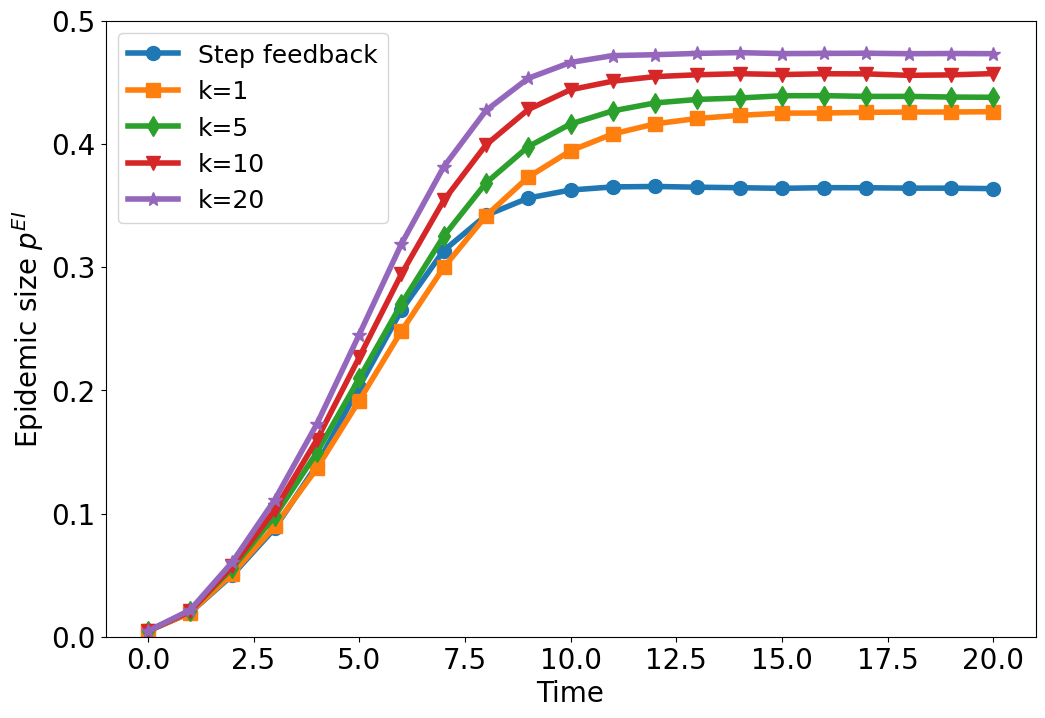

In [76]:
time_scale = torch.arange(mcmc_communities_data[0][0:21,:].shape[0])

# Create a figure with appropriate size
plt.figure(figsize=(12, 8))

# Plot line graphs for different communities
plt.plot(time_scale, mcmc_communities_data[0][0:21,:].mean(dim=1), 'o-', linewidth=4, markersize=10, label='Step feedback')
plt.plot(time_scale, mcmc_communities_data[1][0:21,:].mean(dim=1), 's-', linewidth=4, markersize=10, label=f'k={feedbacks[1]}')
plt.plot(time_scale, mcmc_communities_data[2][0:21,:].mean(dim=1), 'd-', linewidth=4, markersize=10, label=f'k={feedbacks[2]}')
plt.plot(time_scale, mcmc_communities_data[3][0:21,:].mean(dim=1), 'v-', linewidth=4, markersize=10, label=f'k={feedbacks[3]}')
plt.plot(time_scale, mcmc_communities_data[4][0:21,:].mean(dim=1), '*-', linewidth=4, markersize=10, label=f'k={feedbacks[4]}')

# Set y-axis limits from 0 to 0.5
plt.ylim(0, 0.5)
# Add labels and title
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Time', fontsize=20)
plt.ylabel(r'Epidemic size $p^{EI}$', fontsize=20)
plt.legend(fontsize=18)

# Save the figure
plt.savefig('../figs/Feedback/epidemic_size.svg', bbox_inches='tight')
plt.savefig('../figs/Feedback/epidemic_size.png', dpi=600, bbox_inches='tight')
plt.show()

In [77]:
print(mcmc_soc_attention_data[0].shape)
print(mcmc_soc_attention_data[0][0:201:10,...].shape)
print(mcmc_soc_attention_data[0])
print(mcmc_soc_attention_data[1][0:201:10,0,:])

torch.Size([1000, 3, 10])
torch.Size([21, 3, 10])
tensor([[[0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
         [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
         [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000]],

        [[0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
         [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
         [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000]],

        [[0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
         [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000],
         [0.1000, 0.1000, 0.1000,  ..., 0.1000, 0.1000, 0.1000]],

        ...,

        [[0.4880, 0.5000, 0.4920,  ..., 0.4960, 0.4840, 0.4880],
         [0.2940, 0.3000, 0.2960,  ..., 0.2980, 0.2920, 0.2940],
         [0.2940, 0.3000, 0.2960,  ..., 0.2980, 0.2920, 0.2940]],

        [[0.4840, 0.4920, 0.4920,  ..., 0.4880, 0.4640, 0.4880],
         [0.2920, 0.2960, 0.2960,  ..., 0.2940, 0.2820, 0.2940],
         [0.2920, 

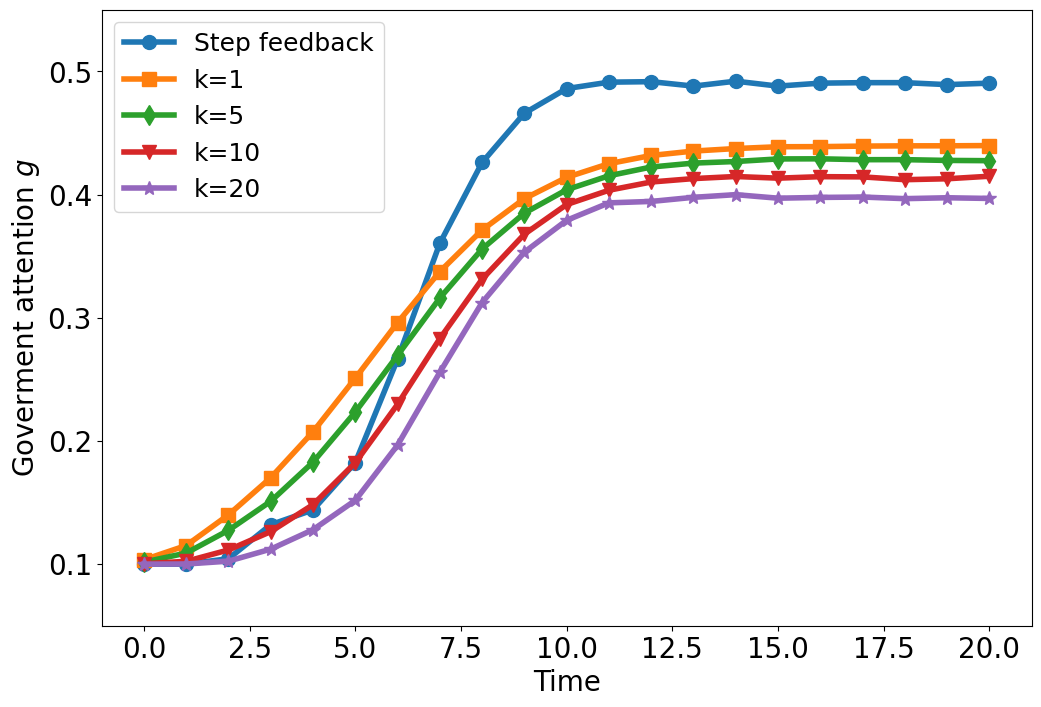

In [78]:
time_scale = torch.arange(mcmc_soc_attention_data[0][0:201:10,0,:].shape[0])
# Create a figure with appropriate size
plt.figure(figsize=(12, 8))

# Plot line graphs for different communities
plt.plot(time_scale, mcmc_soc_attention_data[0][0:201:10,0,:].mean(dim=1), 'o-', linewidth=4, markersize=10, label='Step feedback')
plt.plot(time_scale, mcmc_soc_attention_data[1][0:201:10,0,:].mean(dim=1), 's-', linewidth=4, markersize=10, label=f'k={feedbacks[1]}')
plt.plot(time_scale, mcmc_soc_attention_data[2][0:201:10,0,:].mean(dim=1), 'd-', linewidth=4, markersize=10, label=f'k={feedbacks[2]}')
plt.plot(time_scale, mcmc_soc_attention_data[3][0:201:10,0,:].mean(dim=1), 'v-', linewidth=4, markersize=10, label=f'k={feedbacks[3]}')
plt.plot(time_scale, mcmc_soc_attention_data[4][0:201:10,0,:].mean(dim=1), '*-', linewidth=4, markersize=10, label=f'k={feedbacks[4]}')

# Set y-axis limits from 0 to 0.5
plt.ylim(0.05, 0.55)
# Add labels and title
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Time', fontsize=20)
plt.ylabel(r'Goverment attention $g$', fontsize=20)
plt.legend(fontsize=18)

# Save the figure
plt.savefig('../figs/Feedback/goverment_attention.svg', bbox_inches='tight')
plt.savefig('../figs/Feedback/goverment_attention.png', dpi=600, bbox_inches='tight')
plt.show()

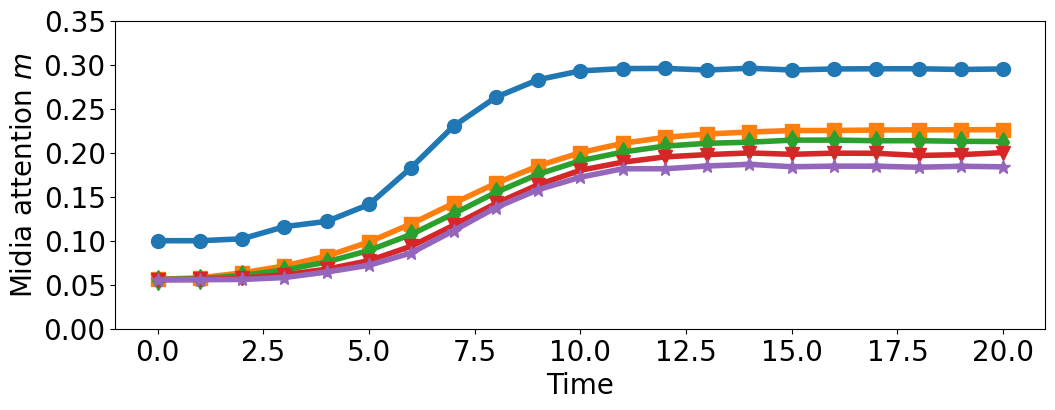

In [79]:
time_scale = torch.arange(mcmc_soc_attention_data[0][0:201:10,0,:].shape[0])
# Create a figure with appropriate size
plt.figure(figsize=(12, 4))

# Plot line graphs for different communities
plt.plot(time_scale, mcmc_soc_attention_data[0][0:201:10,1,:].mean(dim=1), 'o-', linewidth=4, markersize=10, label='Step feedback')
plt.plot(time_scale, mcmc_soc_attention_data[1][0:201:10,1,:].mean(dim=1), 's-', linewidth=4, markersize=10, label=f'k={feedbacks[1]}')
plt.plot(time_scale, mcmc_soc_attention_data[2][0:201:10,1,:].mean(dim=1), 'd-', linewidth=4, markersize=10, label=f'k={feedbacks[2]}')
plt.plot(time_scale, mcmc_soc_attention_data[3][0:201:10,1,:].mean(dim=1), 'v-', linewidth=4, markersize=10, label=f'k={feedbacks[3]}')
plt.plot(time_scale, mcmc_soc_attention_data[4][0:201:10,1,:].mean(dim=1), '*-', linewidth=4, markersize=10, label=f'k={feedbacks[4]}')

# Set y-axis limits from 0 to 0.5
plt.ylim(0.0, 0.35)
# Add labels and title
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Time', fontsize=20)
plt.ylabel(r'Midia attention $m$', fontsize=20)
# plt.legend(fontsize=18)

# Save the figure
plt.savefig('../figs/Feedback/media_attention.svg', bbox_inches='tight')
plt.savefig('../figs/Feedback/media_attention.png', dpi=600, bbox_inches='tight')
plt.show()

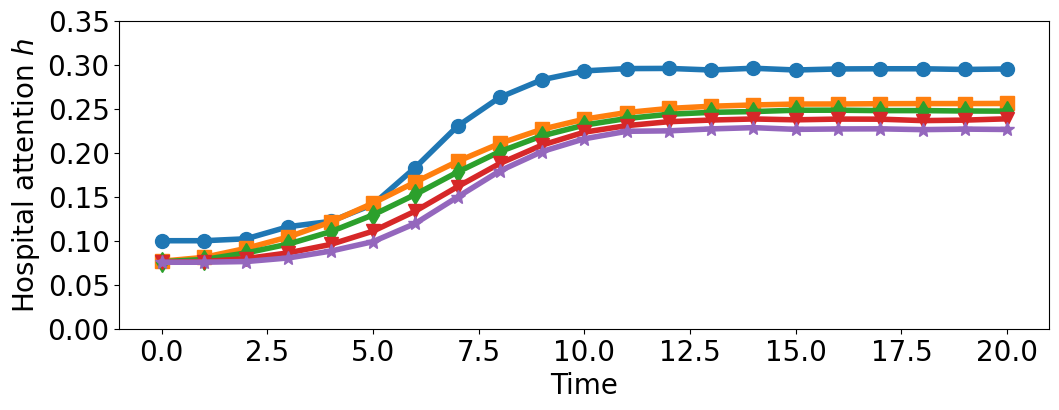

In [80]:
time_scale = torch.arange(mcmc_soc_attention_data[0][0:201:10,0,:].shape[0])
# Create a figure with appropriate size
plt.figure(figsize=(12, 4))

# Plot line graphs for different communities
plt.plot(time_scale, mcmc_soc_attention_data[0][0:201:10,2,:].mean(dim=1), 'o-', linewidth=4, markersize=10, label='Step feedback')
plt.plot(time_scale, mcmc_soc_attention_data[1][0:201:10,2,:].mean(dim=1), 's-', linewidth=4, markersize=10, label=f'k={feedbacks[1]}')
plt.plot(time_scale, mcmc_soc_attention_data[2][0:201:10,2,:].mean(dim=1), 'd-', linewidth=4, markersize=10, label=f'k={feedbacks[2]}')
plt.plot(time_scale, mcmc_soc_attention_data[3][0:201:10,2,:].mean(dim=1), 'v-', linewidth=4, markersize=10, label=f'k={feedbacks[3]}')
plt.plot(time_scale, mcmc_soc_attention_data[4][0:201:10,2,:].mean(dim=1), '*-', linewidth=4, markersize=10, label=f'k={feedbacks[4]}')

# Set y-axis limits from 0 to 0.5
plt.ylim(0.0, 0.35)
# Add labels and title
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.xlabel('Time', fontsize=20)
plt.ylabel(r'Hospital attention $h$', fontsize=20)
# plt.legend(fontsize=18)

# Save the figure
plt.savefig('../figs/Feedback/hospital_attention.svg', bbox_inches='tight')
plt.savefig('../figs/Feedback/hospital_attention.png', dpi=600, bbox_inches='tight')
plt.show()